In [ ]:
from pysr import PySRRegressor
import pandas as pd
import geopandas as gdf
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import geopandas as gpd
import numpy as np

def load_and_preprocess_landslide_data(source_path, total_path, name):
    """
    Load and preprocess landslide inventory data from source and total shapefiles.
    
    Parameters:
    source_path (str): Path to source inventory shapefile
    total_path (str): Path to total inventory shapefile
    
    Returns:
    geopandas.GeoDataFrame: Processed DataFrame with cleaned data and engineered features
    """
    # Load and merge data
    source_df = gdf.read_file(source_path)
    total_df = gdf.read_file(total_path)
    
    # Select relevant columns
    source_geo = source_df[['unique_id', 'area_S', 'Volume',
                        
                        # 'MI', 'MAI', 'angle_S', 'TD_S', 'TH_S', 'MAE_S',
                        # 'SR_S', 'CHM_S', 'E_S', 'WBB_S', 'LWE_S', 'LWF_S', 'AR_S',

                        # '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
                        # '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
                        # '25', '26', '27', '28', '29', 
                        'geometry'
                        ]]
    total_df['area_T'] = total_df.geometry.area
    total_geo = total_df[['unique_id', #'area_T',

                        # 'angle_T', 'TD_T', 'TH_T', 'relative_s', 'hillslope_', 
                        # 'SR_T', 'CHM_T', 'MAE_T', 'E_T', 'WBB_T', 'LW_T', 'LWF_T', 'AR_T',

                        # '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
                        # '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
                        # '25', '26', '27', '28', '29'
                        'geometry'
                        ]]
    
    # Merge datasets
    merged_df = total_geo.merge(source_geo, on='unique_id', how='inner')
    merged_df = gpd.GeoDataFrame(merged_df, geometry='geometry')
    print(type(merged_df))
    merged_df = merged_df.to_crs(epsg=4326)
    # Handle column naming
    if 'area_S' in merged_df.columns:
        merged_df = merged_df.rename(columns={'area_S': 'Area'})
    elif 'Area' not in merged_df.columns:
        print("Warning: 'area_S' not found and 'Area' does not exist. Please check column names.")
    
    # Filter data
    print('Before filtering: ', len(merged_df))
    filtered_df = merged_df[
        (merged_df['Area'] > 1e-9) &
        (merged_df['Volume'] > 1e-9) &
        (merged_df['relative_s'].between(0.09, 1.9)) &
        (merged_df['angle_S'] > 5) &
        (merged_df['MI'].between(0, 2, inclusive='neither')) &
        (merged_df['MAI'] > 0)
    ].copy()
    print('After filtering: ', len(filtered_df))
    
    # Reset index and preserve original
    filtered_df = filtered_df.reset_index(drop=True)
    filtered_df['original_index'] = filtered_df.index
    
    # Feature engineering
    filtered_df['sin_phi'] = np.sin(np.radians(filtered_df['angle_S']))
    # tan phi
    filtered_df['tan_phi'] = np.tan(np.radians(filtered_df['angle_S']))
    filtered_df['logA'] = np.log10(filtered_df['Area'] + 1e-6)
    filtered_df['logV'] = np.log10(filtered_df['Volume'])
    filtered_df['MI_raw'] = filtered_df['MI']
    filtered_df['inv_MI'] = -np.log10(filtered_df['MI']) 
    # divide by inv_MI
    filtered_df['inv_MI2'] = 1/filtered_df['inv_MI'] + 1e-6
    filtered_df['MAI_raw'] = filtered_df['MAI']
    filtered_df['logMAI'] = np.log10(filtered_df['MAI'] + 1e-6)
    filtered_df['Region'] = name

    # Check for infinite values
    # assert not gdf[['logA', 'logV', 'inv_MI', 'logMAI']].isin([np.inf, -np.inf]).any().any(), \
    #     "Infinite values detected in engineered features"
    
    # Replace any remaining inf/-inf with NaNs
    # gdf.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Final null check
    # gdf.dropna(subset=['logV', 'logA', 'inv_MI', 'logMAI'], inplace=True)
    
    return filtered_df

## Data Loading

In [6]:
xx = gpd.read_file(r"..\Data\NZ_source_M1.shp")
xx.columns

Index(['Source_ID', 'GeolCode', 'Method', 'Volume', 'Vol_p1SD', 'Vol_m1SD',
       'Note', 'Reference', 'Shape_Leng', 'Shape_Area', 'unique_id', 'MI',
       'MAI', 'angle_S', 'TD_S', 'TH_S', 'flow_path', 'area', 'perimeter_',
       'SR_S', 'AR_S', 'CHM_S', 'MAE_S', 'E_S', 'WBB_S', 'LWE_S', 'LWF_S',
       'area_S', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', 'geometry'],
      dtype='object')

In [ ]:
# Load and clean data (unchanged)
NZ_M1 = load_and_preprocess_landslide_data(
                                            r"..\Data\NZ_source_M1.shp",
                                            r"..\Data\NZ_total_M1.shp", 
                                            "NZ_M1"
                                                    )

HK = load_and_preprocess_landslide_data(r"..\Data\HK_source.shp",
                                        r"..\Data\HK_total.shp", 
                                        "Hokkaido")
for i in range(30):
    HK.rename(columns={f'{i}_x': f'f{i}s'}, inplace=True)
    HK.rename(columns={f'{i}_y': f'f{i}t'}, inplace=True)

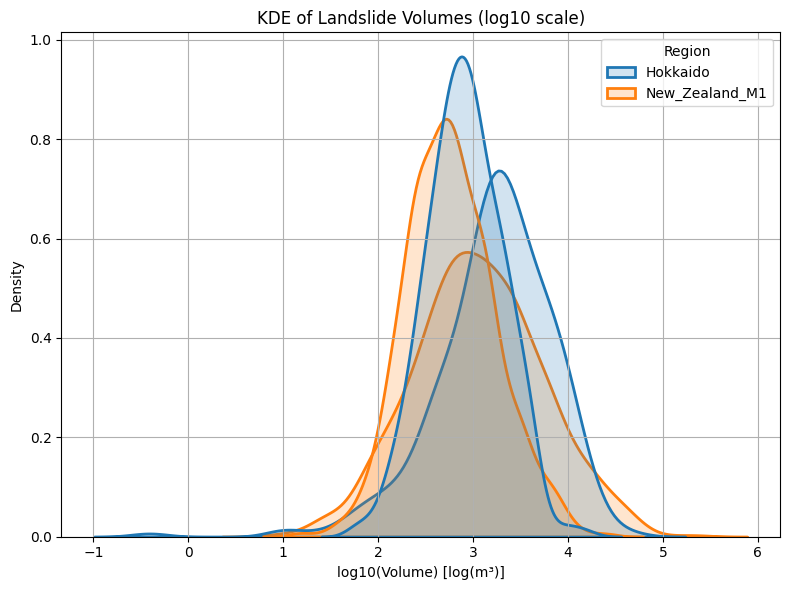

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine all into one dataframe
df_all = pd.concat([HK, NZ_M1], ignore_index=True)
# df_all.to_csv('df_all.csv')
# KDE plot to compare volume distributions
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df_all, x='logV', hue='Region', fill=True, common_norm=False, alpha=0.2, linewidth=2)
sns.kdeplot(data=df_all, x='logA', hue='Region', fill=True, common_norm=False, alpha=0.2, linewidth=2)
plt.title('KDE of Landslide Volumes (log10 scale)')
plt.xlabel('log10(Volume) [log(m³)]')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Individual SR modelling
def PySR_model(df):
    features = ['logA',

        # Source
        'MI', 'MAI', 'angle_S', 'TD_S', 'TH_S', 'MAE_S',
        'SR_S', 'CHM_S', 'E_S', 'WBB_S', 'LWE_S', 'LWF_S',
        'tan_phi', 'sin_phi', 
        'AR_S',

        # 'f0s', 'f1s', 'f2s', 'f3s', 'f4s', 'f5s', 'f6s', 'f7s', 'f8s', 'f9s', 'f10s', 'f11s', 'f12s',
        # 'f13s', 'f14s', 'f15s', 'f16s', 'f17s', 'f18s', 'f19s', 'f20s', 'f21s', 'f22s', 'f23s', 'f24s',
        # 'f25s', 'f26s', 'f27s', 'f28s', 'f29s',

       #Total
       'area_T',
       'angle_T', 'TD_T', 'TH_T', 'relative_s', 'hillslope_', 
       'SR_T', 'CHM_T', 'MAE_T', 'E_T', 'WBB_T', 'LW_T', 'LWF_T',
       'AR_T',
       
    #    'f0t', 'f1t', 'f2t', 'f3t', 'f4t', 'f5t', 'f6t', 'f7t', 'f8t', 'f9t', 'f10t', 'f11t', 'f12t',
    #    'f13t', 'f14t', 'f15t', 'f16t', 'f17t', 'f18t', 'f19t', 'f20t', 'f21t', 'f22t', 'f23t', 'f24t',
    #    'f25t', 'f26t', 'f27t', 'f28t', 'f29t'
       ]

    X = df[
        (df['Area'] > 1e-9) &
        (df['Volume'] > 1e-9) &
        # (df['relative_s'].between(0.09, 1.9)) &
        (df['angle_S'] > 5) &
        (df['MI'].between(0, 2, inclusive='neither')) &
        (df['MAI'] > 0)
    ].copy()

    # Clean X and y simultaneously
    X = X[features].astype(np.float64)

    y = df['logV'].astype(np.float64)

    # Create a mask for valid values in both X and y
    mask = (
        X.replace([np.inf, -np.inf], np.nan).notnull().all(axis=1) &
        np.isfinite(y)
    )

    # Apply cleaning to both X and y
    X_clean = X.loc[mask].copy()
    y_clean = y.loc[mask]

    # Clip extreme values to 1st/99th percentiles
    for col in X_clean.columns:
        lower, upper = np.nanpercentile(X_clean[col], [1, 99])
        X_clean.loc[:, col] = np.clip(X_clean.loc[:, col], lower, upper)

    # Final alignment check
    valid_indices = df.index.intersection(X_clean.index)
    X_clean = X_clean.loc[valid_indices]
    y_clean = y_clean.loc[valid_indices]

    print(f"Cleaned shapes - X: {X_clean.shape}, y: {y_clean.shape}")
    assert len(X_clean) == len(y_clean), "Mismatched sample sizes after cleaning"
    
    # --- Split into train/test ---
    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
    X_train = X_train.replace([np.inf, -np.inf], np.nan).dropna()
    y_train = y_train.loc[X_train.index]
    # --- Initialize PySR ---
    model = PySRRegressor(
        niterations=1000,
        binary_operators=["plus", "sub", "mult", "div"],  # Use named operators
        extra_sympy_mappings={
            'plus': lambda a, b: a + b,
            'sub': lambda a, b: a - b,
            'mult': lambda a, b: a * b,
            'div': lambda a, b: a / b
        },
        constraints={
            'feature_names': ['logA', 'logV', 'sin_phi'],  # Explicit feature names
            'max_ops_per_var': 2
        },
        model_selection="best",  # Select lowest val loss
        elementwise_loss="loss(x, y) = (x - y)^2",
        maxsize=20,
        verbosity=1,
        turbo=True,
        # equation_format='callable',
        random_state=42,
        deterministic=True, parallelism='serial',
        progress=True,
    )

    # --- Fit model ---
    model.fit(X_train, y_train)
    # --- Evaluate model ---
    from sklearn.metrics import r2_score
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"\n🔎 R² on test set: {r2:.4f}")

    # --- Evaluate all candidate models ---
    print("\n🔍 R² scores for all candidate symbolic expressions:")
    for eqn in model.equations_:
        try:
            y_eqn = model.predict(X_test, equation=eqn["equation"])
            r2_local = r2_score(y_test, y_eqn)
            print(f"Complexity {eqn['complexity']:>2} | R² = {r2_local:.4f} | {eqn['equation']}")
        except Exception as e:
            print(f"Skipping equation due to error: {e}")

    # --- Best equation ---
    # print("\n📜 Best symbolic expression (raw):")
    # print(model.get_best().__str__())

In [ ]:
PySR_model(NZ_M1)
print("FINISHED NZ")

Cleaned shapes - X: (1288, 30), y: (1288,)


c:\Users\kusha\anaconda3\envs\geom_AI\lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.250e+05
Progress: 707 / 31000 total iterations (2.281%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.649e-01  0.000e+00  y = 3.0586
3           1.597e-01  5.343e-01  y = logA * 1.1079
5           1.568e-01  9.177e-03  y = (logA * 1.0798) / E_T
7           1.456e-01  3.707e-02  y = logA + ((-3.4508 - MAE_T) * -0.011437)
9           1.453e-01  8.136e-04  y = (((-2.8115 - MAE_T) - MI) * -0.011463) + logA
11          1.446e-01  2.492e-03  y = (((0.55767 - MAE_T) * -0.011181) - (MI * -0.087805)) +...
                                       logA
13          1.444e-01  7.479e-04  y = (((0.1595 * ((1.0867 + MAI) - MAE_T)) - MI) * -0.07317...
                                      ) + logA
17          1.441e-01  4.465e-04  y = (((relative_s / TH_T) / 

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 1.380e+05
Progress: 30474 / 31000 total iterations (98.303%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.512e-01  0.000e+00  y = logA
3           1.597e-01  2.266e-01  y = logA * 1.1079
5           1.460e-01  4.491e-02  y = (MAE_T * 0.012787) + logA
7           1.431e-01  1.003e-02  y = (logA - (SR_S / MAE_T)) * 1.2397
9           1.420e-01  3.707e-03  y = (1.231 * logA) - ((E_S + SR_S) / MAE_T)
11          1.404e-01  5.685e-03  y = (logA + -0.39072) * ((SR_S * (-0.48924 / MAE_T)) + 1.4...
                                      354)
13          1.388e-01  5.888e-03  y = ((SR_S * (-0.54041 / MAE_T)) + 1.4791) * (logA - (E_S ...
                                      / 2.0739))
────────────────────────────────────────────────────────────────────